# 04 — Model Selection

Compare four models on the IEEE-CIS fraud dataset.  
All use `class_weight='balanced'` (or equivalent) — chosen in notebook 03.

| Model | Why |
|-------|-----|
| Logistic Regression | Linear baseline, fast, interpretable |
| Random Forest | Non-linear, handles feature interactions |
| HistGradientBoosting | Sklearn histogram-based boosting (LightGBM-style) |
| XGBoost | Industry-standard gradient boosting, often best on tabular data |

**Targets to beat (rule-based baseline):** ROC-AUC > 0.631, Fraud F1 > 0.093

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../data/ecommerce_fraud.duckdb')
df  = con.execute('SELECT * FROM fct_fraud_signals').df()
print(df.shape)

(590540, 22)


## 1. Feature preparation

In [2]:
features = [
    'order_amount', 'order_hour', 'account_age_days', 'orders_on_day',
    'customer_avg_order_amount', 'customer_ip_mismatch_count',
    'is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity',
    'payment_method', 'product_category',
]

X = pd.get_dummies(df[features], columns=['payment_method', 'product_category'], drop_first=True)
for c in ['is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity']:
    X[c] = X[c].astype(int)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Fraud rate  train: {y_train.mean():.2%}  test: {y_test.mean():.2%}")

Train: (472432, 17)  |  Test: (118108, 17)
Fraud rate  train: 3.50%  test: 3.50%


## 2. Train all models

In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=12, n_jobs=-1, random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, class_weight='balanced',
        max_depth=6, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, verbosity=0,
    ),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train.values
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test.values
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'fraud_f1': f1_score(y_test, y_pred),
    }
    print(f"AUC={results[name]['roc_auc']:.3f}  F1={results[name]['fraud_f1']:.3f}")

Training Logistic Regression... 

AUC=0.747  F1=0.146
Training Random Forest... 

AUC=0.848  F1=0.233
Training HistGradientBoosting... 

AUC=0.854  F1=0.205
Training XGBoost... 

AUC=0.881  F1=0.248


## 3. Classification reports

In [4]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f" {name}  (AUC={r['roc_auc']:.3f})")
    print(f"{'='*50}")
    print(classification_report(y_test, r['y_pred'],
                                target_names=['Legit', 'Fraud'], digits=3))


 Logistic Regression  (AUC=0.747)
              precision    recall  f1-score   support

       Legit      0.981     0.759     0.856    113975
       Fraud      0.083     0.601     0.146      4133

    accuracy                          0.753    118108
   macro avg      0.532     0.680     0.501    118108
weighted avg      0.950     0.753     0.831    118108


 Random Forest  (AUC=0.848)
              precision    recall  f1-score   support

       Legit      0.986     0.851     0.913    113975
       Fraud      0.141     0.674     0.233      4133

    accuracy                          0.844    118108
   macro avg      0.564     0.762     0.573    118108
weighted avg      0.957     0.844     0.890    118108


 HistGradientBoosting  (AUC=0.854)
              precision    recall  f1-score   support

       Legit      0.989     0.800     0.884    113975
       Fraud      0.119     0.744     0.205      4133

    accuracy                          0.798    118108
   macro avg      0.554     

## 4. ROC and Precision-Recall curves

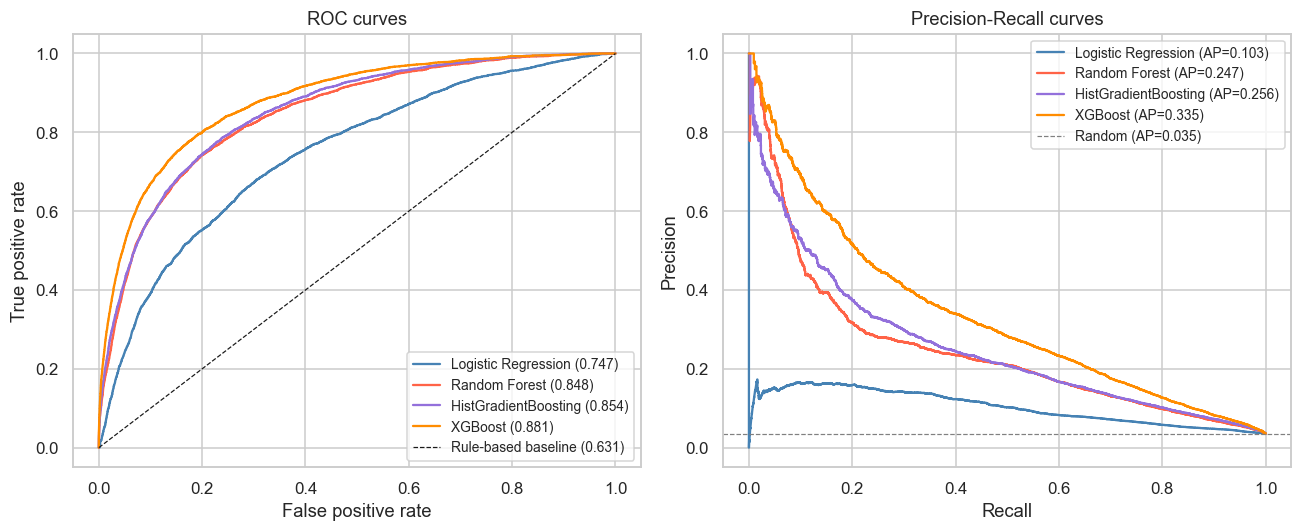

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'tomato', 'mediumpurple', 'darkorange']

ax = axes[0]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f"{name} ({r['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Rule-based baseline (0.631)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves')
ax.legend(fontsize=9)

ax = axes[1]
for (name, r), color in zip(results.items(), colors):
    prec_c, rec_c, _ = precision_recall_curve(y_test, r['y_prob'])
    ax.plot(rec_c, prec_c, color=color,
            label=f"{name} (AP={r['avg_precision']:.3f})")
ax.axhline(y_test.mean(), color='gray', linestyle='--', linewidth=0.8,
           label=f'Random (AP={y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Summary table

In [6]:
summary = pd.DataFrame([
    {'model': name, 'roc_auc': r['roc_auc'],
     'avg_precision': r['avg_precision'], 'fraud_f1': r['fraud_f1']}
    for name, r in results.items()
])
summary.loc[len(summary)] = {
    'model': '-- rule-based baseline --',
    'roc_auc': 0.631, 'avg_precision': 0.052, 'fraud_f1': 0.093
}
summary = summary.set_index('model').round(3).sort_values('roc_auc', ascending=False)
print(summary.to_string())

best_name = summary.index[0]
print(f"\nWinner: {best_name}")

                           roc_auc  avg_precision  fraud_f1
model                                                      
XGBoost                      0.881          0.335     0.248
HistGradientBoosting         0.854          0.256     0.205
Random Forest                0.848          0.247     0.233
Logistic Regression          0.747          0.103     0.146
-- rule-based baseline --    0.631          0.052     0.093

Winner: XGBoost


## 6. Confusion matrix — best model

Model: XGBoost
  True  Negatives:  96,024
  False Positives:  17,951
  False Negatives:   1,006
  True  Positives:   3,127


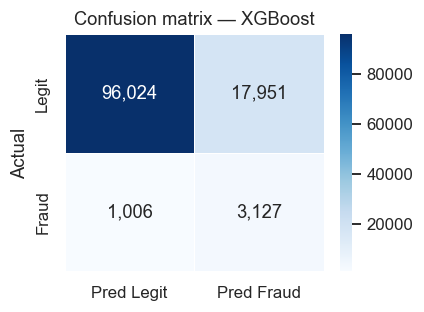

In [7]:
best_name = summary.index[0]
best = results[best_name]

cm = confusion_matrix(y_test, best['y_pred'])
tn, fp, fn, tp = cm.ravel()
print(f"Model: {best_name}")
print(f"  True  Negatives: {tn:>7,}")
print(f"  False Positives: {fp:>7,}")
print(f"  False Negatives: {fn:>7,}")
print(f"  True  Positives: {tp:>7,}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    pd.DataFrame(cm, index=['Legit','Fraud'], columns=['Pred Legit','Pred Fraud']),
    annot=True, fmt=',d', cmap='Blues', ax=ax, linewidths=0.5
)
ax.set_title(f'Confusion matrix — {best_name}')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Feature importance — best model

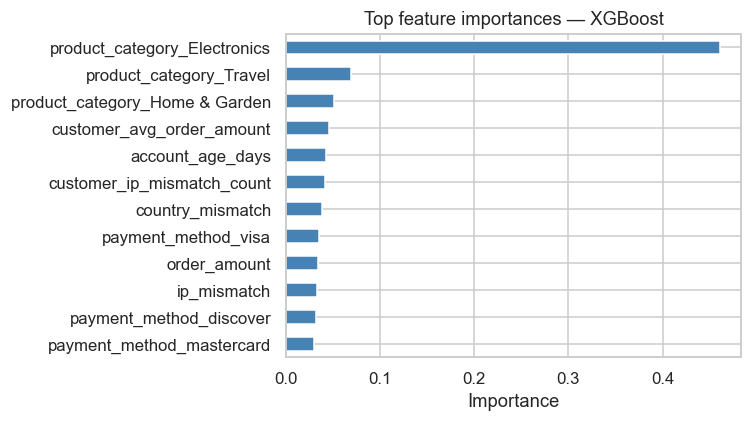

In [8]:
best_model = results[best_name]['model']
feat_names = list(X.columns)
X_te = X_test_sc if best_name == 'Logistic Regression' else X_test.values

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feat_names)
elif hasattr(best_model, 'coef_'):
    imp = pd.Series(np.abs(best_model.coef_[0]), index=feat_names)
else:
    # permutation importance works for any model
    perm = permutation_importance(best_model, X_te, y_test,
                                  n_repeats=5, random_state=42, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=feat_names)

imp = imp.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Top feature importances — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()